In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer

# Load data
train_data = pd.read_csv('../titanic/train.csv')
test_data = pd.read_csv('../titanic/test.csv')
gender_submission_data = pd.read_csv('../titanic/gender_submission.csv')

In [8]:
# Define training features
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

# Data preprocessing
train_data['Age'] = train_data['Age'].fillna(train_data['Age'].median())
train_data['Fare'] = train_data['Fare'].fillna(train_data['Fare'].median())
test_data['Age'] = test_data['Age'].fillna(test_data['Age'].median())
test_data['Fare'] = test_data['Fare'].fillna(test_data['Fare'].median())

train_data['Embarked'] = train_data['Embarked'].fillna(train_data['Embarked'].mode()[0])
test_data['Embarked'] = test_data['Embarked'].fillna(test_data['Embarked'].mode()[0])

# Convert categorical features 'Sex' and 'Embarked' to numeric values
le_sex = LabelEncoder()
le_embarked = LabelEncoder()

train_data['Sex'] = le_sex.fit_transform(train_data['Sex'])
train_data['Embarked'] = le_embarked.fit_transform(train_data['Embarked'])

test_data['Sex'] = le_sex.transform(test_data['Sex'])
test_data['Embarked'] = le_embarked.transform(test_data['Embarked'])

# Check for NaN values in the test set and fill them
imputer = SimpleImputer(strategy='most_frequent')
test_data[features] = imputer.fit_transform(test_data[features])

In [9]:
# Select features for training
X_train = train_data[features]
y_train = train_data['Survived']

# Split training data into train and validation sets
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# AdaBoost model with a shallow decision tree base classifier
ada_model = AdaBoostClassifier(DecisionTreeClassifier(max_depth=1), n_estimators=50, algorithm='SAMME', random_state=42)

# Train the model
ada_model.fit(X_train_split, y_train_split)

# Evaluate on the validation set
y_val_pred = ada_model.predict(X_val_split)
accuracy = accuracy_score(y_val_split, y_val_pred)
print(f'Validation accuracy: {accuracy * 100:.2f}%')

Validation accuracy: 79.89%


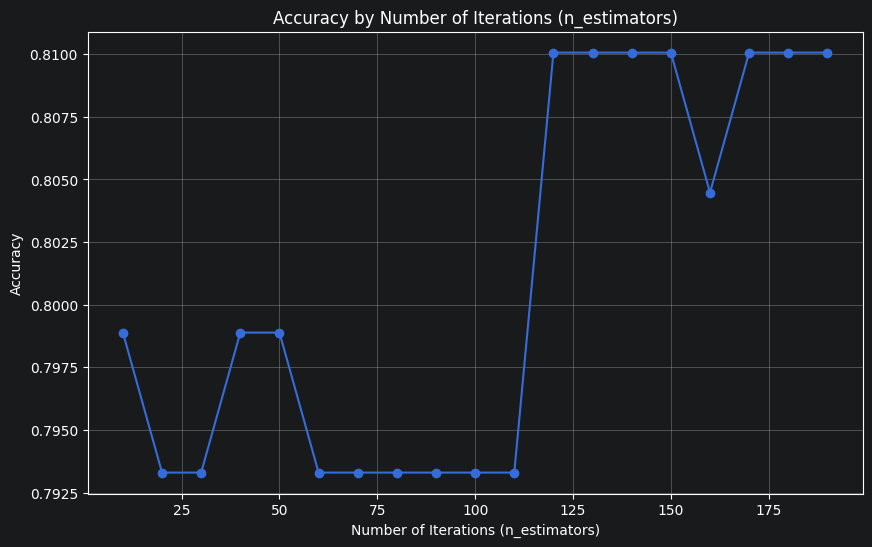

In [10]:
# Visualize accuracy by number of iterations
n_estimators_range = np.arange(10, 200, 10)
accuracies = []

for n_estimators in n_estimators_range:
    model = AdaBoostClassifier(DecisionTreeClassifier(max_depth=1), n_estimators=n_estimators, algorithm='SAMME', random_state=42)
    model.fit(X_train_split, y_train_split)
    y_val_pred = model.predict(X_val_split)
    accuracies.append(accuracy_score(y_val_split, y_val_pred))

plt.figure(figsize=(10, 6))
plt.plot(n_estimators_range, accuracies, marker='o')
plt.title('Accuracy by Number of Iterations (n_estimators)')
plt.xlabel('Number of Iterations (n_estimators)')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

In [11]:
# Predict on test data
X_test = test_data[features]
test_predictions = ada_model.predict(X_test)

# Save the result
output = pd.DataFrame({'PassengerId': test_data['PassengerId'], 'Survived': test_predictions})
output.to_csv('submission.csv', index=False)

print("The 'submission.csv' file with results has been saved.")

# Print the first 10 predicted values
print("First 10 predictions and actual values:")
print(pd.DataFrame({'Predicted': test_predictions[:10], 'Real': gender_submission_data['Survived'][:10]}))

The 'submission.csv' file with results has been saved.
First 10 predictions and actual values:
   Predicted  Real
0          0     0
1          1     1
2          0     0
3          0     0
4          1     1
5          0     0
6          1     1
7          0     0
8          1     1
9          0     0
